## Particles from the Plume to the Atlantic

* Release particles from the plume every month (1st day) for 3 years (2022-2025)
* Release time 2022 to 2025
* Number of particles =  10_000
* Release depth = (0,10)
* Compare the Wc and W

In [1]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

### Copernicus Data A grid

In [2]:
pathUV= '/work/bk1450/b383184/Amazon/Atlantic/data/UV'
pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'

ufiles = sorted(glob(f"{pathUV}/U_20*.nc"))
vfiles = sorted(glob(f"{pathUV}/V_20*.nc"))
wfiles = sorted(glob(f"{pathW}/W_20*.nc"))

In [3]:
## number of particles
num_particles = 10_000

lon = -48.9 * np.ones(shape=(num_particles, ))
lat = np.linspace(1.5, -1, num_particles)

# 1. Center
lon0 = lon.mean()
lat0 = lat.mean()

# 2. Centered coordinates
x = lon - lon0
y = lat - lat0

# 3. Rotation
theta = np.deg2rad(45)
x_rot = x * np.cos(theta) - y * np.sin(theta)
y_rot = x * np.sin(theta) + y * np.cos(theta)

# 4. Back to lon/lat
lon_start = x_rot + lon0
lat_start = y_rot + lat0

In [4]:
## parameters

## set the tracking time
days = 900
minutes = 20

## record the particles every timestep of
hours=6

## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
            }

variables = {"U": "uo",
             "V": "vo",
             "W": "wo",}

dimensions={'lon':'longitude',
            'lat':'latitude',
            'time':'time',
            'depth': "depth"}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
)

##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

## Time and depth initial conditios
time_origin=np.array([str(fieldset.time_origin)],dtype='datetime64[ns]')
time = np.repeat(time_origin, num_particles)  # Assign the same time to all particles
depth = np.random.uniform(0,10, size=num_particles)  # Choose random depths

# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = lon_start,
    lat = lat_start,
    depth=depth,
    time=time
) 

rnd=str(np.random.randint(1234))

out_path = '../data/tracks/' #path to store the particle zarr
out_fn = 'Parcels_run_'+rnd

output_file = pset.ParticleFile(name=out_path+out_fn, 
                                outputdt=timedelta(hours=hours))

In [8]:
fieldset.time_origin

2022-06-01T00:00:00.000000000

In [ ]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=days),
    dt=timedelta(minutes=minutes),
    output_file= output_file
)

### Plotting

In [19]:
from cmocean import cm # for oceanography-specific colormaps
from itertools import zip_longest
from functools import reduce
from operator import add
from pathlib import Path
import tqdm
from xhistogram.xarray import histogram as xhist
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [14]:
out_path = '../data/tracks/'
out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn+'.zarr')
ds_traj = ds_traj.compute()
ds_traj

  0%|          | 0/77760000.0 [2:58:00<?, ?it/s]


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/coding/times.py:650: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/coding/times.py:650: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/coding/times.py:650: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/coding/times.py:650: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)


<xarray.Dataset> Size: 720MB
Dimensions:     (trajectory: 10000, obs: 3600)
Coordinates:
  * obs         (obs) int32 14kB 0 1 2 3 4 5 6 ... 3594 3595 3596 3597 3598 3599
  * trajectory  (trajectory) int64 80kB 10017 10039 10073 ... 19996 19998 19999
Data variables:
    lat         (trajectory, obs) float32 144MB 1.131 nan ... -0.7471 -0.7471
    lon         (trajectory, obs) float32 144MB -49.78 nan nan ... -48.08 -48.08
    time        (trajectory, obs) datetime64[ns] 288MB 2022-06-01 ... 2024-11...
    z           (trajectory, obs) float32 144MB 0.3051 nan nan ... 9.911 9.911
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

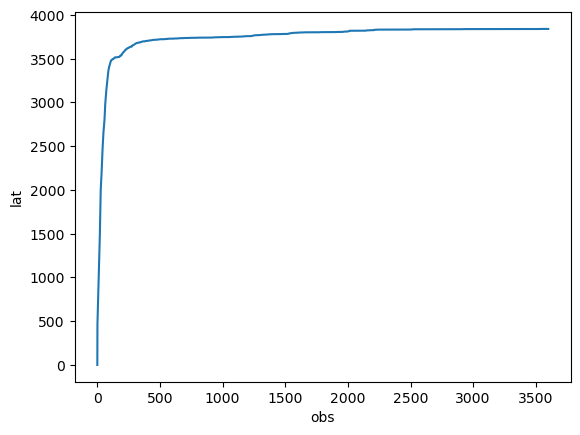

In [15]:
ds_traj.lat.isnull().sum('trajectory').plot(label='A grid')

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


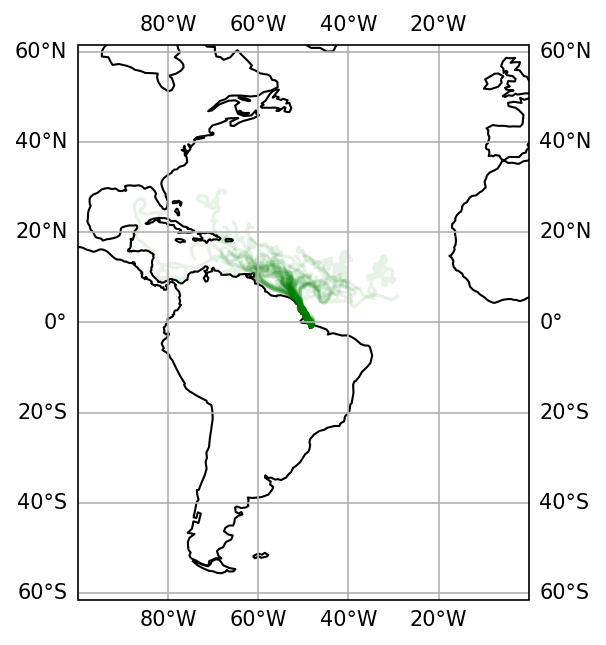

In [20]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

for n in range(ds_traj.sizes["trajectory"]):
    ax.plot(
        *ds_traj.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.1,
        transform=ccrs.PlateCarree(),
    )

ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    np.min(fieldset.U.grid.lat),
    np.max(fieldset.U.grid.lat),
])
ax.gridlines(draw_labels=True);


In [26]:
lon_bins = np.linspace(ds_traj.lon.min().compute().data[()], ds_traj.lon.max().compute().data[()], 40*2)
lat_bins = np.linspace(ds_traj.lat.min().compute().data[()], ds_traj.lat.max().compute().data[()], 40*2)

obs_counts = xhist(
    ds_traj.lon,
    ds_traj.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

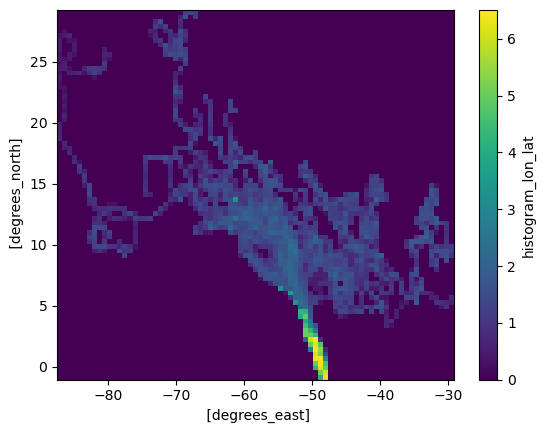

In [31]:
np.log10(obs_counts.sum('obs')+1).plot(x='lon', y='lat')

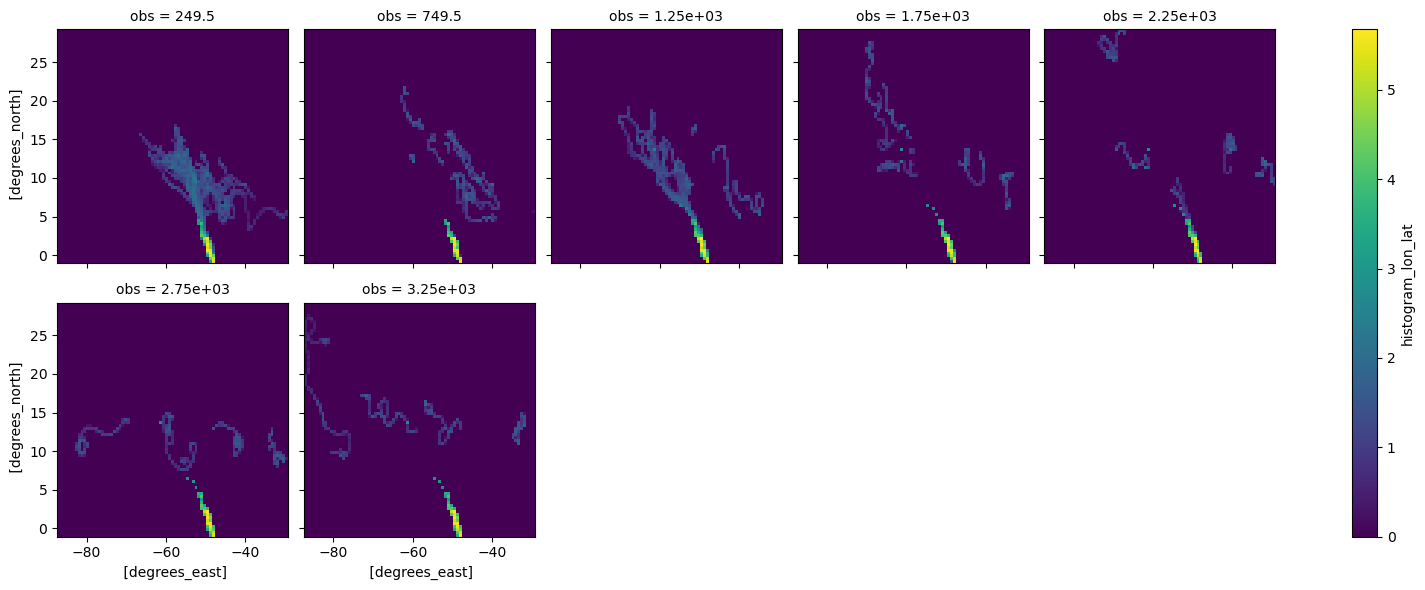

In [35]:
np.log10(obs_counts.coarsen(obs=500, boundary="trim").sum()+1).plot(x="lon", y="lat", col="obs", col_wrap=5)